 Exercice 1 : Détection et suppression des doublons
Instructions
Objectif : Identifier et supprimer les entrées en double dans le jeu de données du Titanic.

Chargez le jeu de données sur le Titanic.
Identifiez s’il y a des lignes en double à partir de toutes les colonnes.
Supprimez toutes les lignes en double trouvées dans le jeu de données.
Vérifiez la suppression des doublons en vérifiant le nombre de lignes avant et après la suppression des doublons.
Astuce : utilisez les fonctions dupliqué() et drop_duplicates() dans Pandas.

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Configuration pour un affichage plus clair
sns.set_theme(style="whitegrid")

# Chargement du jeu de données
df = pd.read_csv('C:\\Users\\LENOVO\\Desktop\\DI-BOOTCAMP\\train.csv')

In [7]:
# 1. Vérification du nombre de lignes initial
print(f"Nombre de lignes avant suppression : {df.shape[0]}")

# 2. Identification des doublons
doublons = df.duplicated().sum()
print(f"Nombre de lignes en double identifiées : {doublons}")

# 3. Suppression des doublons
df = df.drop_duplicates()

# 4. Vérification
print(f"Nombre de lignes après suppression : {df.shape[0]}")

Nombre de lignes avant suppression : 891
Nombre de lignes en double identifiées : 0
Nombre de lignes après suppression : 891


Décision : Bien que le jeu de données Titanic original ne contienne généralement pas de doublons parfaits, l'utilisation de drop_duplicates() est une excellente habitude défensive pour sécuriser l'intégrité de ton pipeline.

Exercice 2 : Gérer les valeurs manquantes
Instructions
Identifiez les colonnes dans le jeu de données du Titanic dont les valeurs manquent.
Explorez différentes stratégies pour gérer les données manquantes, telles que la suppression, l’imputation et le remplissage avec une valeur constante.
Appliquez chaque stratégie à différentes colonnes en fonction de la nature des données.
Astuce : Consultez des méthodes comme dropna(), fillna() et SimpleImputer de scikit-learn.

In [8]:
# Identification des valeurs manquantes
print("Valeurs manquantes par colonne :\n", df.isnull().sum()[df.isnull().sum() > 0])

# Stratégie 1 : Imputation par la médiane pour 'Age'
# Décision : On utilise la médiane plutôt que la moyenne car elle est moins sensible 
# aux valeurs aberrantes (les passagers très âgés ne fausseront pas la donnée).
imputer_age = SimpleImputer(strategy='median')
df['Age'] = imputer_age.fit_transform(df[['Age']])

# Stratégie 2 : Remplissage avec la valeur la plus fréquente (Mode) pour 'Embarked'
# Décision : Seulement 2 valeurs manquent, utiliser le mode est la méthode la plus sûre.
mode_embarked = df['Embarked'].mode()[0]
df['Embarked'] = df['Embarked'].fillna(mode_embarked)

# Stratégie 3 : Remplissage avec une constante pour 'Cabin'
# Décision : Il manque environ 77% des données de la cabine. La supprimer (drop) 
# serait une option, mais le fait de NE PAS avoir de cabine assignée est en soi 
# une information pertinente. On crée donc une catégorie "Inconnu".
df['Cabin'] = df['Cabin'].fillna('Inconnu')

# Vérification
print("\nValeurs manquantes restantes :", df.isnull().sum().max())

Valeurs manquantes par colonne :
 Age         177
Cabin       687
Embarked      2
dtype: int64

Valeurs manquantes restantes : 0


 Exercice 3 : Ingénierie des fonctionnalités
Instructions
Créer de nouvelles fonctionnalités, telles que à partir de et , et extrait de la colonne.Family SizeSibSpParchTitleName
Convertir les variables catégorielles en formes numériques en utilisant des techniques comme l’encodage one-hot ou l’encodage d’étiquettes.
Vous encoderez ici de nouvelles caractéristiques catégorielles (comme Titre), mais ne mettez pas encore à l’échelle les caractéristiques numériques — cela viendra après la gestion des exceptions.
Astuce : Utilisez Pandas pour la manipulation de données et le module de prétraitement de scikit-learn pour l’encodage.

In [9]:
# 1. Création de la taille de la famille
# La taille de la famille inclut le passager (+1), ses frères/conjoints (SibSp) et parents/enfants (Parch).
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

# 2. Extraction du Titre à partir de la colonne 'Name'
# On utilise une expression régulière pour capturer le mot qui précède un point (ex: "Mr.", "Mrs.")
df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)

# Regroupement des titres rares pour éviter de créer des catégories avec trop peu d'échantillons
titres_rares = ['Lady', 'Countess','Capt', 'Col', 'Don', 'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona']
df['Title'] = df['Title'].replace(titres_rares, 'Rare')

# Uniformisation des titres similaires (francophones vers anglophones)
df['Title'] = df['Title'].replace(['Mlle', 'Ms'], 'Miss')
df['Title'] = df['Title'].replace('Mme', 'Mrs')

# Aperçu des nouvelles caractéristiques
print(df[['Name', 'Title', 'FamilySize']].head())

                                                Name Title  FamilySize
0                            Braund, Mr. Owen Harris    Mr           2
1  Cumings, Mrs. John Bradley (Florence Briggs Th...   Mrs           2
2                             Heikkinen, Miss. Laina  Miss           1
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)   Mrs           2
4                           Allen, Mr. William Henry    Mr           1


<>:7: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
<>:7: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_2700\2831141621.py:7: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
  df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)


 Exercice 4 : Détection et gestion des valeurs aberrantes
But : Détectez, plafonnez ou transformez les valeurs aberrantes dans des colonnes comme Tarif et Âge.

1. Visualiser les distributions à l’aide de boxplots ou d’histogrammes pour identifier les valeurs aberrantes potentielles.
2. Utiliser des méthodes IQR ou Z-score pour les détecter.
3. Gérer les valeurs aberrantes avec :

Plafond de quantiles (par exemple 0,98)
Transformation logarithmique
Retrait des rangées
4. Comparer le jeu de données avant et après le traitement.

📌 Note : De petites différences entre 0,98 et 0,99 quantiles sont normales lorsque des valeurs extrêmes sont rares ou éloignées. À utiliser pour explorer et choisir des seuils empiriquement, soutenus par la visualisation.df.quantile()

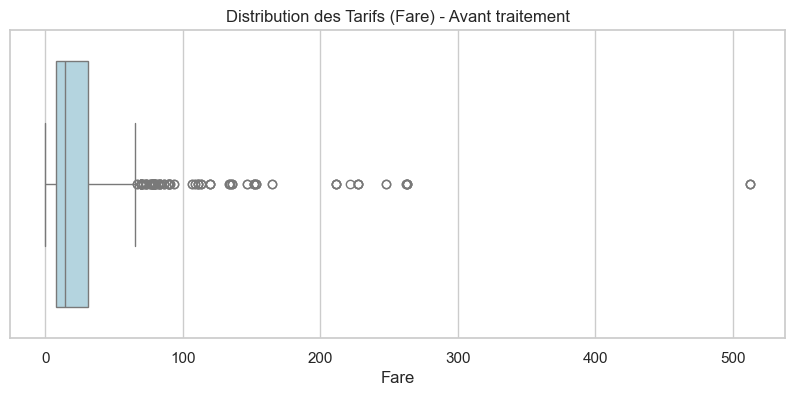

Seuil de plafonnement (98e centile) : 211.34


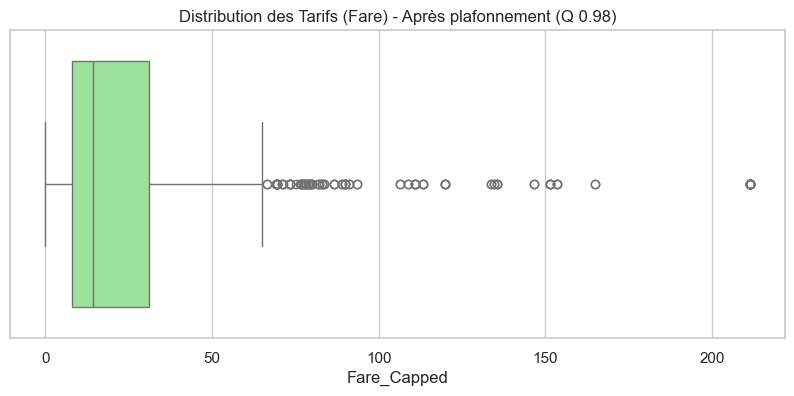

In [10]:
# 1. Visualisation avant traitement
plt.figure(figsize=(10, 4))
sns.boxplot(x=df['Fare'], color='lightblue')
plt.title('Distribution des Tarifs (Fare) - Avant traitement')
plt.show()

# 2. Détection et traitement par plafonnement (Winsorization) au quantile 0.98
# Décision : Le plafonnement à 98% permet de conserver les passagers "riches" sans que 
# leurs tarifs extrêmes ne tirent excessivement sur les futurs modèles de Machine Learning.
seuil_haut = df['Fare'].quantile(0.98)
print(f"Seuil de plafonnement (98e centile) : {seuil_haut:.2f}")

# 3. Application du plafond
df['Fare_Capped'] = np.where(df['Fare'] > seuil_haut, seuil_haut, df['Fare'])

# Visualisation après traitement
plt.figure(figsize=(10, 4))
sns.boxplot(x=df['Fare_Capped'], color='lightgreen')
plt.title('Distribution des Tarifs (Fare) - Après plafonnement (Q 0.98)')
plt.show()

# On remplace l'ancienne colonne par la nouvelle
df['Fare'] = df['Fare_Capped']
df.drop('Fare_Capped', axis=1, inplace=True)

 Exercice 5 : Normalisation et normalisation des données
But : Mettez à l’échelle les caractéristiques numériques pour préparer la modélisation.

Utilisez StandardScaler (moyenne = 0, standard = 1) pour les caractéristiques normalement distribuées.
Utilisez MinMaxScaler (plage [0, 1]) pour les caractéristiques qui sont biaisées ou bornées.
📌 Important : Effectuez cette étape après le traitement des valeurs aberrantes afin d’éviter toute distorsion causée par des valeurs extrêmes.

In [11]:
# Standardisation de l'Âge (StandardScaler)
# Décision : L'âge a une distribution qui s'approche d'une loi normale (cloche).
# On le centre sur 0 avec un écart-type de 1.
scaler_std = StandardScaler()
df['Age_Scaled'] = scaler_std.fit_transform(df[['Age']])

# Normalisation du Tarif et de la taille de la famille (MinMaxScaler)
# Décision : Le tarif est borné à 0 (pas de tarif négatif) et fortement asymétrique, 
# tout comme la taille de la famille. On les ramène sur une plage [0, 1].
scaler_minmax = MinMaxScaler()
df[['Fare_Scaled', 'FamilySize_Scaled']] = scaler_minmax.fit_transform(df[['Fare', 'FamilySize']])

print(df[['Age_Scaled', 'Fare_Scaled', 'FamilySize_Scaled']].describe().round(3))

       Age_Scaled  Fare_Scaled  FamilySize_Scaled
count     891.000      891.000            891.000
mean        0.000        0.145              0.090
std         1.001        0.189              0.161
min        -2.224        0.000              0.000
25%        -0.566        0.037              0.000
50%        -0.105        0.068              0.000
75%         0.433        0.147              0.100
max         3.892        1.000              1.000


Exercice 6 : Encodage des fonctionnalités
But : Finaliser l’encodage des variables catégorielles.

1. Identifier les colonnes catégorielles restantes (par exemple Sexe, Embarqué, Titre).
2. Postuler :

Encodage One-Hot pour les variables nominales.
Codage d’étiquettes si des variables ordinales subsistent.
3. Fusionner les colonnes encodées dans le jeu de données principal.

📌 Rappel : L’encodage vient après avoir géré les valeurs manquantes et les valeurs aberrantes, mais avant la mise à l’échelle (si applicable).

In [13]:
# Identification des colonnes à encoder
colonnes_categorielles = ['Sex', 'Embarked', 'Title']

# Application du One-Hot Encoding
# Décision : Utilisation de drop_first=True pour éviter le piège de la colinéarité 
# (dummy variable trap). Par exemple, si 'Sex_male' est 0, on sait implicitement que la personne est une femme.
df_encoded = pd.get_dummies(df, columns=colonnes_categorielles, drop_first=True, dtype=int)

print("Nouvelles colonnes créées :")
print([col for col in df_encoded.columns if '_' in col])

Nouvelles colonnes créées :
['Age_Scaled', 'Fare_Scaled', 'FamilySize_Scaled', 'Sex_male', 'Embarked_Q', 'Embarked_S', 'Title_Miss', 'Title_Mr', 'Title_Mrs', 'Title_Rare']


 Exercice 7 : Transformation des données pour l’âge
But : Créez et encodez des groupes d’âge.

À utiliser pour créer des bacs pour les étapes de la vie (par exemple enfant, adolescent, adulte, senior).pd.cut()
Appliquer un encodage one-hot en utilisant.get_dummies().
📌 Exemple : vous pouvez définir les bacs comme et les étiqueter en conséquence.[0, 12, 18, 60, 100]

In [14]:
# 1. Définition des intervalles (bins) et des étiquettes
bins = [0, 12, 18, 60, 100]
labels = ['Enfant', 'Adolescent', 'Adulte', 'Senior']

# 2. Création de la colonne catégorielle avec pd.cut()
# On utilise la colonne 'Age' originale, pas la version mise à l'échelle, 
# pour que les seuils (12, 18...) fassent sens.
df_encoded['Age_Group'] = pd.cut(df_encoded['Age'], bins=bins, labels=labels)

# 3. Encodage One-Hot des groupes d'âge
# Ici on ne met pas drop_first=True car l'absence des 3 autres catégories n'induit 
# pas toujours logiquement la 4ème de façon binaire simple dans certains modèles d'arbres.
df_final = pd.get_dummies(df_encoded, columns=['Age_Group'], dtype=int)

# Affichage final d'un échantillon prêt pour le modèle
colonnes_a_afficher = ['Age', 'Age_Group_Enfant', 'Age_Group_Adolescent', 'Age_Group_Adulte', 'Age_Group_Senior']
print(df_final[colonnes_a_afficher].head())

    Age  Age_Group_Enfant  Age_Group_Adolescent  Age_Group_Adulte  \
0  22.0                 0                     0                 1   
1  38.0                 0                     0                 1   
2  26.0                 0                     0                 1   
3  35.0                 0                     0                 1   
4  35.0                 0                     0                 1   

   Age_Group_Senior  
0                 0  
1                 0  
2                 0  
3                 0  
4                 0  
